# RoPE

在理论部分，我们已经介绍了**RoPE**的原理了，本篇就用Python实现一下

[参考知乎解析](https://zhuanlan.zhihu.com/p/359502624)

[RoPE 论文](https://arxiv.org/pdf/2104.09864)

[RoPE Pytorch 实现](https://github.com/JunnYu/RoFormer_pytorch)

## 远程衰减

在理论部分我们已经知道，RoPE作用后的向量的**模长是不变的**，只是根据向量在序列中的位置$m$，对维度两两分组旋转这个向量，因此就把$\vec{q}$和$\vec{k}$的模长设为1便于比较；


那么以相对位置$(m - n)$为横轴，$\sum_{i=0}^{d/2 - 1} \cos((m - n)\theta_i)$为纵轴绘制一个图像，观察二者内积值随着相对距离的变化

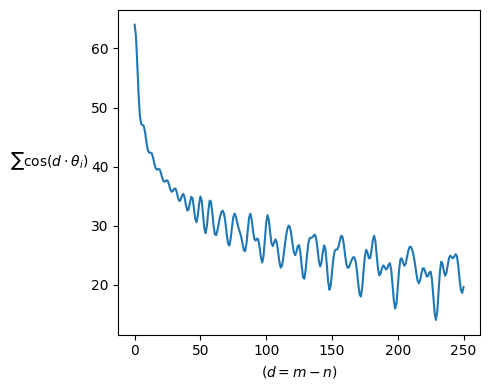

In [4]:
import numpy as np
import matplotlib.pyplot as plt


HEAD_DIM = 128
MAX_DIST = 250


def draw(head_dim:int, max_dist:int):
    num_pairs = head_dim//2
    i = np.arange(num_pairs)
    theta_i = 10000.0 ** (-2*i / head_dim)

    relative_dist = np.arange(max_dist+1)

    scores = []
    for dist in relative_dist:
        score = np.sum(np.cos(dist*theta_i))
        scores.append(score)

    scores_norm = scores / scores[0]

    plt.figure(figsize=(5, 4))
    plt.plot(relative_dist, scores)
    plt.xlabel('$(d = m - n)$')
    plt.ylabel(r'$\sum \cos(d \cdot \theta_i)$', rotation=0, labelpad=30)

    plt.tight_layout()
    plt.show()


draw(HEAD_DIM, MAX_DIST)


可以看到，计算的内积值是震荡性衰减的，相对距离较远时，内积值已经比最初时小了很多了，也就让注意力给予相对位置较远的token更小的权重了

## RoPE实现

公式如下:

$$
\begin{pmatrix}
q_0 \\ q_1 \\ q_2 \\ q_3 \\ \vdots \\ q_{d-2} \\ q_{d-1}
\end{pmatrix}
\otimes
\begin{pmatrix}
\cos m\theta_0 \\ \cos m\theta_0 \\ \cos m\theta_1 \\ \cos m\theta_1 \\ \vdots \\ \cos m\theta_{d/2-1} \\ \cos m\theta_{d/2-1}
\end{pmatrix}
+
\begin{pmatrix}
-q_1 \\ q_0 \\ -q_3 \\ q_2 \\ \vdots \\ -q_{d-1} \\ q_{d-2}
\end{pmatrix}
\otimes
\begin{pmatrix}
\sin m\theta_0 \\ \sin m\theta_0 \\ \sin m\theta_1 \\ \sin m\theta_1 \\ \vdots \\ \sin m\theta_{d/2-1} \\ \sin m\theta_{d/2-1}
\end{pmatrix}
$$

In [1]:
import torch
import torch.nn as nn
import math
from typing import Tuple


class RoPE(nn.Module):
    def __init__(self, head_dim:int = 128, max_seq_len:int = 1024, base: float = 10000.0):
        super().__init__()

        self.head_dim = head_dim
        self.base = base
        self.max_seq_len = max_seq_len

        # [head_dim//2]
        theta_i = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))

        # [max_seq_len]
        pos = torch.arange(max_seq_len).float()
        # [max_seq_len, head_dim//2]，这里进行了广播，得到每个位置的m*theta_i
        m_theta_i = pos[:, None] * theta_i[None, :]

        self.register_buffer('cos_cached', m_theta_i.cos())  # (max_seq_len, head_dim//2)
        self.register_buffer('sin_cached', m_theta_i.sin())  # (max_seq_len, head_dim//2)

    def forward(self, q:torch.Tensor, k:torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        seq_len = q.shape[1]

        # 都是[seq_len, head_dim//2]
        cos = self.cos_cached[:seq_len, :]  
        sin = self.sin_cached[:seq_len, :]

        q_rot = self._rotate(q, cos, sin)
        k_rot = self._rotate(k, cos, sin)
        
        return q_rot, k_rot
    
    def _rotate(self, x:torch.Tensor, cos:torch.Tensor, sin:torch.Tensor):
        # [seq_len, head_dim] -> [1, seq_len, 1, head_dim]，便于广播计算
        cos = cos.unsqueeze(0).unsqueeze(2)  
        sin = sin.unsqueeze(0).unsqueeze(2)

        # x: [bs, seq_len, num_heads, head_dim]，在head_dim上按照奇偶分组
        x_even, x_odd = x[..., 0::2], x[..., 1::2]

        # 按奇偶位分别计算
        out_even = x_even * cos + (-x_odd) * sin
        out_odd = x_odd * cos + x_even * sin
        
        # 拼回[0, 1, 2, 3....]的顺序
        # stack -> [bs, seq_len, num_heads, head_dim//2, 2]
        # flatten ->  [bs, seq_len, num_heads, head_dim]
        return torch.stack([out_even, out_odd], dim=-1).flatten(-2)


In [8]:
BATCH_SIZE = 4
HEAD_DIM = 128
NUM_HEADS = 4
SEQ_LEN = 500


rope = RoPE(HEAD_DIM)
q = torch.randn(BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM)
k = torch.randn(BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM)
q_rot, k_rot = rope(q, k)
print('before RoPE, K/V size:')
print(q.size(), k.size())
print('after RoPE, K/V size:')
print(q_rot.size(), k_rot.size())


before RoPE, K/V size:
torch.Size([4, 4, 500, 128]) torch.Size([4, 4, 500, 128])
after RoPE, K/V size:
torch.Size([4, 4, 500, 128]) torch.Size([4, 4, 500, 128])
